# Random forest Classifier Ecoli

Ini adalah tahap modeling klasifikasi data ecoli menggunakan metode Random Forest dengan kondisi

Data ecoli yang belum di lakukan oversampling

Data ecoli yang sudah di lakukan oversampling menggunakan SMOTE

Data ecoli yang sudah di lakukan oversampling menggunakan ADASYN

kemudian di bandingkan apakah ada penambahan akurasi saat setelah data di lakukan oversampling

# Library yang digunakan

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Koneksi ke database MySql dan Kondisi Data sebelum dilakukan Oversampling

In [11]:
engine = create_engine("mysql+pymysql://root:@localhost:3306/ecoli")

# ambil data dari tabel
df = pd.read_sql("SELECT * FROM ecoli;", engine)
class_counts = df['class_label'].value_counts().sort_index()
nt = df.drop(columns=["class_label", "id_protein"])
ns = df["class_label"]
print("\nInfo Dataset:")
df


Info Dataset:


,id_protein,feature1,feature2,feature3,feature4,feature5,feature6,feature7,class_label
0,AAS_ECOLI,0.44,0.52,0.48,0.5,0.43,0.47,0.54,im
1,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
2,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
3,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
4,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
...,...,...,...,...,...,...,...,...,...
332,XYLA_ECOLI,0.16,0.43,0.48,0.5,0.54,0.27,0.37,cp
333,XYLE_ECOLI,0.69,0.39,0.48,0.5,0.57,0.76,0.79,im
334,XYLF_ECOLI,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp
335,YCEE_ECOLI,0.52,0.54,0.48,0.5,0.62,0.76,0.79,im


# Hasil Data setelah dilakukan oversampling menggunakan ADASYN

In [18]:
data_adasyn = pd.read_csv("../balance/hasil_oversampling_ADASYN.csv")
x_adasyn = data_adasyn.drop(columns=["class_label"])
y_adasyn = data_adasyn["class_label"]

data_adasyn

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,class_label
0,0.440000,0.520000,0.48,0.5,0.430000,0.470000,0.540000,im
1,0.490000,0.290000,0.48,0.5,0.560000,0.240000,0.350000,cp
2,0.070000,0.400000,0.48,0.5,0.540000,0.350000,0.440000,cp
3,0.560000,0.400000,0.48,0.5,0.490000,0.370000,0.460000,cp
4,0.590000,0.490000,0.48,0.5,0.520000,0.450000,0.360000,cp
...,...,...,...,...,...,...,...,...
1150,0.661748,0.520951,0.48,0.5,0.688097,0.764602,0.790951,im
1151,0.453950,0.427441,0.48,0.5,0.368844,0.743255,0.625006,im
1152,0.531648,0.681910,0.48,0.5,0.390337,0.873745,0.856704,im
1153,0.567383,0.488093,0.48,0.5,0.552483,0.760000,0.790000,im


# Hasil Data setelah dilakukan oversampling menggunakan SMOTE

In [36]:
data_smote = pd.read_csv("../balance/ecoli_balanced_smote.csv")
x_smote = data_smote.drop(columns=["class_label"])
y_smote = data_smote["class_label"]
data_smote

,id_protein,feature1,feature2,feature3,feature4,feature5,feature6,feature7,class_label
0,P0001,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.000000,class_label
1,P0002,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.000000,class_label
2,P0003,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.000000,class_label
3,P0004,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.000000,class_label
4,P0005,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.000000,class_label
...,...,...,...,...,...,...,...,...,...
1282,P1283,0.643762,0.568749,0.48,0.5,0.487498,0.697498,0.212511,pp
1283,P1284,0.620166,0.829503,0.48,0.5,0.460000,0.359172,0.398178,pp
1284,P1285,0.696860,0.727270,0.48,0.5,0.413720,0.810171,0.804471,pp
1285,P1286,0.709695,0.849695,0.48,0.5,0.186488,0.523207,0.218244,pp


# Hasil Akurasi Klasifikasi Data Ecoli yang Belum di Oversampling Adasyn

accuracy_score : 0.9117647058823529
Classification Report:
               precision    recall  f1-score   support

          cp       0.96      0.96      0.96        25
          im       0.91      0.95      0.93        21
         imU       1.00      0.60      0.75         5
          om       1.00      0.80      0.89         5
         omL       0.00      0.00      0.00         1
          pp       0.79      1.00      0.88        11

    accuracy                           0.91        68
   macro avg       0.78      0.72      0.73        68
weighted avg       0.91      0.91      0.90        68



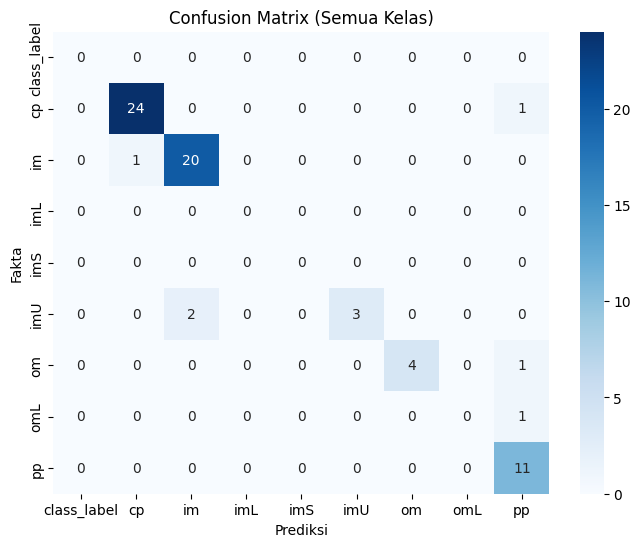

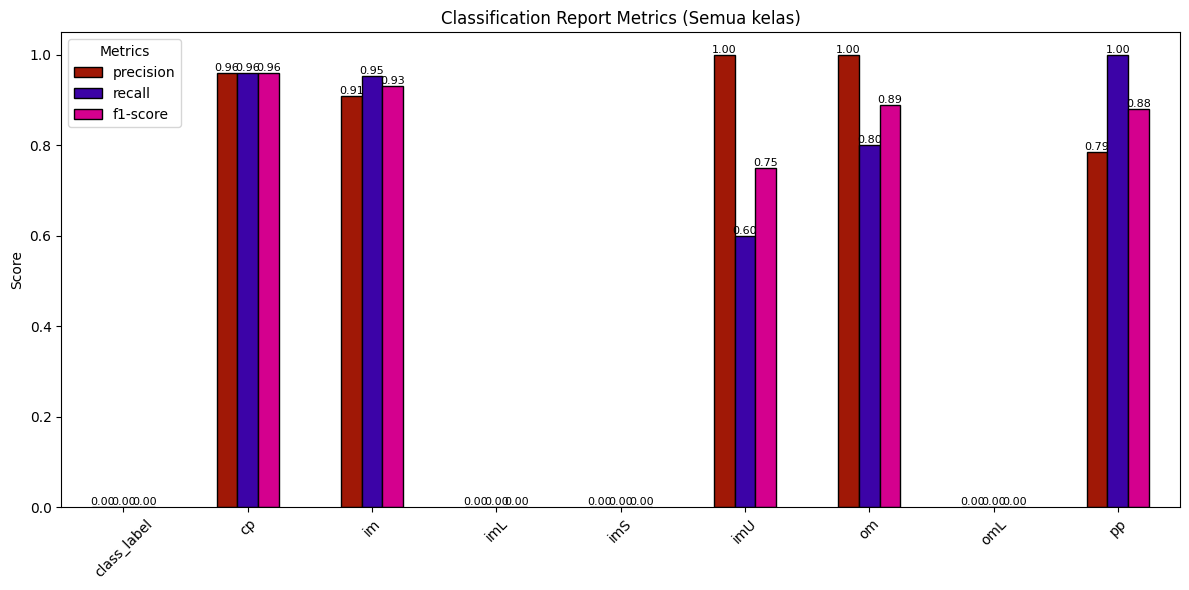

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    nt, ns, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

prediksi = rf.predict(X_test)

print(f"accuracy_score : {accuracy_score(y_test, prediksi)}")
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train, y_test]))

cm = confusion_matrix(y_test, prediksi, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train, y_test]))

report = classification_report(
    y_test, prediksi, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Hasil Akurasi Klasifikasi Data Ecoli yang Sudah di Oversampling menggunakan adasyn

In [40]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

prediksi_smote = rf.predict(X_test_smote)

print(f"accuracy_score : {accuracy_score(y_test_smote, prediksi_smote)}")
print("Classification Report:\n", classification_report(y_test_smote, prediksi_smote, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

report = classification_report(
    y_test_smote, prediksi_smote, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'P0359'

# Hasil Akurasi Klasifikasi Data Ecoli yang Sudah di Oversampling menggunakan SMOTE